In [6]:
import numpy as np
import matplotlib.pyplot as plt

In [7]:
# Predicted ligands
ligands = ['L22','L23','L24','L25','L26','L27','L28','L29','L30','L31','L32','L33','L34','L35','L36','L37','L38','L39','L40','L41']

In [8]:
# Predicted ΔΔG‡ values (replace with your values)
predicted = [0.228,0.540,1.577,-0.188,-0.106,-0.264,-0.497,-0.538,-0.553,0.375,0.420,0.601,0.738,1.319,1.363,1.167,1.307,0.848,0.635,0.977]

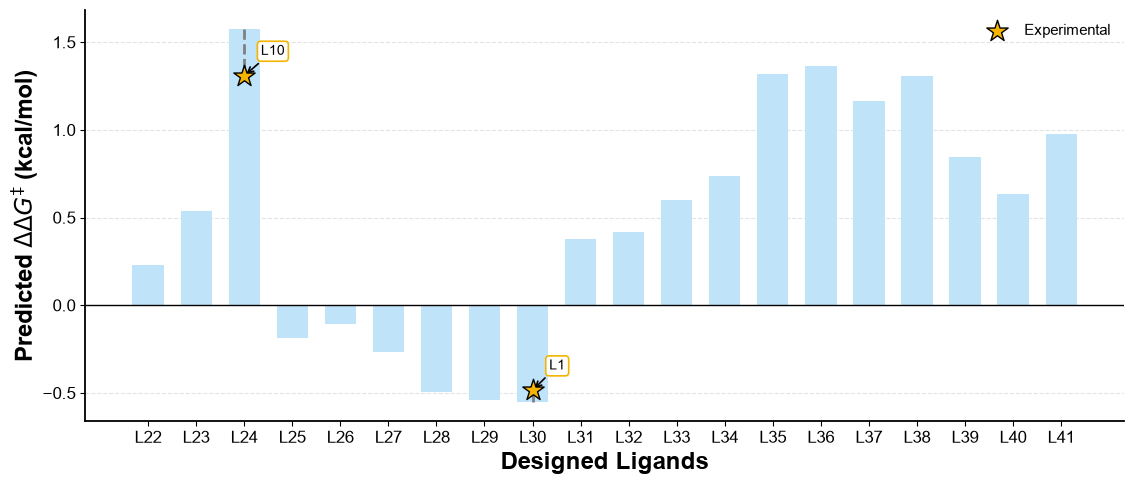

In [9]:
# Replace with your experimental values
exp = {
    'L24': {'value':1.309, 'label':'L10'},
    'L30': {'value':-0.485, 'label':'L1'}
}

x = np.arange(len(ligands))

# -----------------------
# Figure
# -----------------------
plt.rcParams.update({
    'font.size':12,
    'axes.linewidth':1.3,
    'font.family':'Arial'
})

fig, ax = plt.subplots(figsize=(11.5,5))

# Bars
bars = ax.bar(
    x,
    predicted,
    width=0.65,
    color='#BFE3F8',
    linewidth=1.2,
    zorder=2
)

# Experimental references
first = True
for ligand, info in exp.items():

    idx = ligands.index(ligand)

    # connector
    ax.plot([idx, idx],
            [predicted[idx], info['value']],
            ls='--',
            lw=2,
            color='gray',
            zorder=3)

    # star marker
    ax.scatter(idx,
               info['value'],
               marker='*',
               s=260,
               color='#F4B400',
               edgecolor='black',
               linewidth=1,
               zorder=5,
               label='Experimental' if first else None)

    # annotation box
    ax.annotate(info['label'],
                xy=(idx, info['value']),
                xytext=(12,15),
                textcoords='offset points',
                fontsize=10,
                bbox=dict(boxstyle='round,pad=0.25',
                          fc='white',
                          ec='#F4B400',
                          lw=1.2),
                arrowprops=dict(arrowstyle='->',
                                lw=1.2,
                                color='black'))

    first=False

# Zero line
ax.axhline(0,color='black',lw=1)

# Grid
ax.grid(axis='y',
        linestyle='--',
        alpha=0.35)

# Labels
ax.set_xticks(x)
ax.set_xticklabels(ligands)

ax.set_ylabel(r'Predicted $\Delta\Delta G^{\ddag}$ (kcal/mol)',
              fontsize=17, fontweight='bold')

ax.set_xlabel('Designed Ligands',
              fontsize=17, fontweight="bold")

# Remove unnecessary spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Legend
ax.legend(frameon=False, fontsize=11)

# Tight layout for better spacing
fig.tight_layout()

# Save high-resolution figure for publication
fig.savefig("in-silico screening.png", dpi=600, bbox_inches="tight")

plt.show()

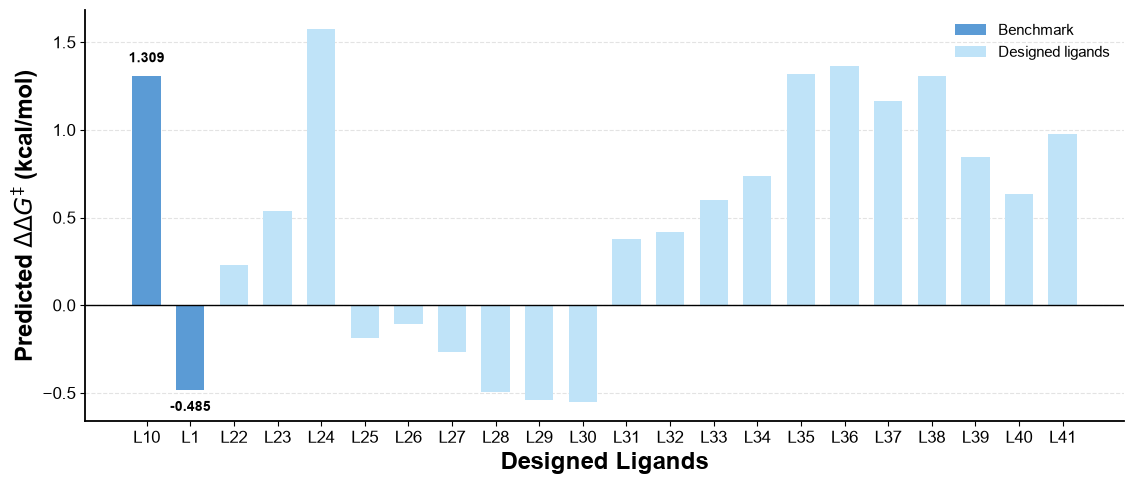

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# Experimental benchmark values
# --------------------------------------------------
benchmark = {
    'L10': 1.309,
    'L1': -0.485
}

# --------------------------------------------------
# Figure settings
# --------------------------------------------------
plt.rcParams.update({
    'font.size': 12,
    'axes.linewidth': 1.3,
    'font.family': 'Arial'
})

# x positions
x_benchmark = np.arange(2)
x_ligands = np.arange(2, len(ligands) + 2)

# --------------------------------------------------
# Figure
# --------------------------------------------------
fig, ax = plt.subplots(figsize=(11.5, 5))

# --------------------------------------------------
# Colors
# --------------------------------------------------
normal_blue = '#BFE3F8'
benchmark_blue = '#5B9BD5'   # slightly darker blue

# --------------------------------------------------
# Benchmark bars: L10 and L1
# --------------------------------------------------
benchmark_values = [
    benchmark['L10'],
    benchmark['L1']
]

ax.bar(
    x_benchmark,
    benchmark_values,
    width=0.65,
    color=benchmark_blue,
    linewidth=1.2,
    zorder=2,
    label='Benchmark'
)

# --------------------------------------------------
# Predicted bars for designed ligands
# --------------------------------------------------
ax.bar(
    x_ligands,
    predicted,
    width=0.65,
    color=normal_blue,
    linewidth=1.2,
    zorder=2,
    label='Designed ligands'
)

# --------------------------------------------------
# Labels for benchmark values
# --------------------------------------------------
for i, (ligand, value) in enumerate(benchmark.items()):

    if value >= 0:
        ax.text(
            i,
            value + 0.06,
            f'{value:.3f}',
            ha='center',
            va='bottom',
            fontsize=10,
            fontweight='bold'
        )
    else:
        ax.text(
            i,
            value - 0.06,
            f'{value:.3f}',
            ha='center',
            va='top',
            fontsize=10,
            fontweight='bold'
        )

# --------------------------------------------------
# Zero line
# --------------------------------------------------
# Zero line
ax.axhline(0,color='black',lw=1)

# --------------------------------------------------
# Grid
# --------------------------------------------------
ax.grid(
    axis='y',
    linestyle='--',
    alpha=0.35,
    zorder=0
)

# --------------------------------------------------
# X-axis
# --------------------------------------------------
all_labels = ['L10', 'L1'] + list(ligands)

ax.set_xticks(
    np.arange(len(all_labels))
)

ax.set_xticklabels(
    all_labels
)

# --------------------------------------------------
# Axis labels
# --------------------------------------------------
ax.set_ylabel(
    r'Predicted $\Delta\Delta G^{\ddag}$ (kcal/mol)',
    fontsize=17,
    fontweight='bold'
)

ax.set_xlabel(
    'Designed Ligands',
    fontsize=17,
    fontweight='bold'
)

# --------------------------------------------------
# Spines
# --------------------------------------------------
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# --------------------------------------------------
# Legend
# --------------------------------------------------
ax.legend(
    frameon=False,
    fontsize=11
)

# --------------------------------------------------
# Layout
# --------------------------------------------------
fig.tight_layout()

# --------------------------------------------------
# Save
# --------------------------------------------------
fig.savefig(
    "in-silico screening.png",
    dpi=600,
    bbox_inches='tight'
)

plt.show()